In [ ]:
import imageio
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.utils import save_image
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision.utils import make_grid




to_pil_image = transforms.ToPILImage()
def image_to_vid(images):
    imgs = [np.array(to_pil_image(img)) for img in images]
    imageio.mimsave('./outputs/generated_images.gif', imgs)
def save_reconstructed_images(recon_images, epoch):
    save_image(recon_images.cpu(), f"./outputs/output{epoch}.jpg")
def save_loss_plot(train_loss, valid_loss):
    # loss plots
    plt.figure(figsize=(10, 7))
    plt.plot(train_loss, color='orange', label='train loss')
    plt.plot(valid_loss, color='red', label='validataion loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig('./outputs/loss.jpg')
    plt.show()

In [ ]:
from tqdm import tqdm
import torch 
def final_loss(mse_loss, mu, logvar):
    """
    This function will add the reconstruction loss (BCELoss) and the 
    KL-Divergence.
    KL-Divergence = 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    :param mse_loss: recontruction loss
    :param mu: the mean from the latent vector
    :param logvar: log variance from the latent vector
    """
    MSE = mse_loss 
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

In [69]:
def train(encoder, decoder, dataloader, dataset, device, optimizer, criterion):
    encoder.train()
    decoder.train()
    running_loss = 0.0
    counter = 0
    for i, data in tqdm(enumerate(dataloader), total=int(len(dataset)/dataloader.batch_size)):
        counter += 1
        data = data[0]
        data = data.to(device)
        optimizer.zero_grad()
        z, mu, log_var = encoder(data)
        reconstruction = decoder(z, mu, log_var)
        
        # reconstruction, mu, logvar = model(data)
        bce_loss = criterion(reconstruction, data)
        loss = final_loss(bce_loss, mu, log_var)
        loss.backward()
        running_loss += loss.item()
        optimizer.step()
    train_loss = running_loss / counter 
    return train_loss

In [86]:
def validate(encoder, decoder, dataloader, dataset, device, criterion):
    encoder.eval()
    decoder.eval()
    running_loss = 0.0
    counter = 0
    with torch.no_grad():
        for i, data in tqdm(enumerate(dataloader), total=int(len(dataset)/dataloader.batch_size)):
            counter += 1
            data= data[0]
            data = data.to(device)
            z, mu, log_var = encoder(data)
            reconstruction = decoder(z, mu, log_var)

            # reconstruction, mu, logvar = model(data)
            bce_loss = criterion(reconstruction, data)
            loss = final_loss(bce_loss, mu, log_var)
            running_loss += loss.item()
        
            # save the last batch input and output of every epoch
            if i == int(len(dataset)/dataloader.batch_size) - 1:
                recon_images = reconstruction
    val_loss = running_loss / counter
    return val_loss, recon_images

In [87]:
kernel_size = 4 # (4, 4) kernel
init_channels = 8 # initial number of filters
image_channels = 1 # MNIST images are grayscale
latent_dim = 2 # latent dimension for sampling - było 16

In [88]:
# define a Conv VAE
class EncoderVAE(nn.Module):
    def __init__(self):
        super(EncoderVAE, self).__init__()
 
        # encoder
        self.enc1 = nn.Conv2d(
            in_channels=image_channels, out_channels=init_channels, kernel_size=kernel_size, 
            stride=2, padding=1
        )
        self.enc2 = nn.Conv2d(
            in_channels=init_channels, out_channels=init_channels*2, kernel_size=kernel_size, 
            stride=2, padding=1
        )
        self.enc3 = nn.Conv2d(
            in_channels=init_channels*2, out_channels=init_channels*4, kernel_size=kernel_size, 
            stride=2, padding=1
        )
        self.enc4 = nn.Conv2d(
            in_channels=init_channels*4, out_channels=64, kernel_size=kernel_size, 
            stride=2, padding=0
        )
        # fully connected layers for learning representations
        self.fc1 = nn.Linear(64, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_log_var = nn.Linear(128, latent_dim)


    def reparameterize(self, mu, log_var):
        """
        :param mu: mean from the encoder's latent space
        :param log_var: log variance from the encoder's latent space
        """
        std = torch.exp(0.5*log_var) # standard deviation
        eps = torch.randn_like(std) # `randn_like` as we need the same size
        sample = mu + (eps * std) # sampling
        return sample
    

    def forward(self, x):
        # encoding
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.enc3(x))
        x = F.relu(self.enc4(x))
        batch, _, _, _ = x.shape
        x = F.adaptive_avg_pool2d(x, 1).reshape(batch, -1)
        hidden = self.fc1(x)
        # get `mu` and `log_var`
        mu = self.fc_mu(hidden)
        log_var = self.fc_log_var(hidden)
        # get the latent vector through reparameterization
        z = self.reparameterize(mu, log_var)
        return z, mu, log_var



In [89]:
class DecoderVAE(nn.Module):
    def __init__(self):
        super(DecoderVAE, self).__init__()
        
        # decoder 
        self.fc2 = nn.Linear(latent_dim, 64)
        
        self.dec1 = nn.ConvTranspose2d(
            in_channels=64, out_channels=init_channels*8, kernel_size=kernel_size, 
            stride=1, padding=0
        )
        self.dec2 = nn.ConvTranspose2d(
            in_channels=init_channels*8, out_channels=init_channels*4, kernel_size=kernel_size, 
            stride=2, padding=1
        )
        self.dec3 = nn.ConvTranspose2d(
            in_channels=init_channels*4, out_channels=init_channels*2, kernel_size=kernel_size, 
            stride=2, padding=1
        )
        self.dec4 = nn.ConvTranspose2d(
            in_channels=init_channels*2, out_channels=image_channels, kernel_size=kernel_size, 
            stride=2, padding=1
        )

    def decode(self, z, mu, log_var):
    # decoding
      z = self.fc2(z)
      z = z.view(-1, 64, 1, 1)
      x = F.relu(self.dec1(z))
      x = F.relu(self.dec2(x))
      x = F.relu(self.dec3(x))
      reconstruction = torch.sigmoid(self.dec4(x))
      return reconstruction #, mu, log_var
    
 
    def forward(self, z, mu, log_var):
        # z, mu, log_var = self.encode(x)
        return self.decode(z, mu, log_var)

In [94]:

matplotlib.style.use('ggplot')

In [95]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# initialize the model
# model = 
encoder = EncoderVAE().to(device)
decoder = DecoderVAE().to(device)
params = [param for param in encoder.parameters()] + [param for param in decoder.parameters()]
# decoder = DecoderVAE().to(device)
# set the learning parameters
lr = 0.001
epochs = 100
batch_size = 64
optimizer = optim.Adam(params, lr=lr)
criterion = nn.MSELoss(reduction='sum')
# a list to save all the reconstructed images in PyTorch grid format
grid_images = []

In [96]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])
# training set and train data loader
trainset = torchvision.datasets.MNIST(
    root='../input', train=True, download=True, transform=transform
)
trainloader = DataLoader(
    trainset, batch_size=batch_size, shuffle=True
)
# validation set and validation data loader
testset = torchvision.datasets.MNIST(
    root='../input', train=False, download=True, transform=transform
)
testloader = DataLoader(
    testset, batch_size=batch_size, shuffle=False
)

In [97]:
train_loss = []
valid_loss = []
for epoch in range(epochs):
    train_epoch_loss = train(
        encoder, decoder, trainloader, trainset, device, optimizer, criterion
    )
    valid_epoch_loss, recon_images = validate(
        encoder, decoder, testloader, testset, device, criterion
    )
    train_loss.append(train_epoch_loss)
    valid_loss.append(valid_epoch_loss)
    # save the reconstructed images from the validation loop
    # save_reconstructed_images(recon_images, epoch+1)
    # convert the reconstructed images to PyTorch image grid format
    image_grid = make_grid(recon_images.detach().cpu())
    grid_images.append(image_grid)
    if epoch % 20 == 0:
      print(f"Epoch {epoch+1} of {epochs}")
      print(f'Scores for {epoch}-th epoch are: ')
      print(f"Train Loss: {train_epoch_loss:.4f}")
      print(f"Val Loss: {valid_epoch_loss:.4f}")

938it [00:16, 58.21it/s]                         
157it [00:02, 59.45it/s]


Epoch 1 of 100
Scores for 0-th epoch are: 
Train Loss: 3648.4376
Val Loss: 2983.0046


938it [00:16, 56.50it/s]                         
157it [00:02, 76.32it/s]                         
938it [00:16, 58.05it/s]                         
157it [00:02, 62.98it/s]                         
938it [00:16, 58.15it/s]                         
157it [00:02, 78.31it/s]                         
938it [00:16, 55.90it/s]                         
157it [00:02, 69.75it/s]                         
938it [00:17, 54.59it/s]                         
157it [00:02, 76.38it/s]                         
938it [00:16, 55.76it/s]
157it [00:02, 78.46it/s]                         
938it [00:16, 58.09it/s]                         
157it [00:02, 76.06it/s]                         
938it [00:17, 53.78it/s]                         
157it [00:02, 75.54it/s]                         
938it [00:17, 54.88it/s]                         
157it [00:02, 60.45it/s]                         
938it [00:16, 57.27it/s]                         
157it [00:02, 75.37it/s]                         
938it [00:16, 56.82it/s] 

Epoch 21 of 100
Scores for 20-th epoch are: 
Train Loss: 2315.9725
Val Loss: 2353.6417


938it [00:16, 55.39it/s]                         
157it [00:02, 73.32it/s]                         
938it [00:16, 55.52it/s]                         
157it [00:02, 58.17it/s]                         
938it [00:16, 55.30it/s]                         
157it [00:02, 76.92it/s]                         
938it [00:16, 57.15it/s]                         
157it [00:02, 63.92it/s]                         
938it [00:16, 57.74it/s]                         
157it [00:02, 76.89it/s]                         
938it [00:16, 55.58it/s]                         
157it [00:02, 73.17it/s]                         
938it [00:16, 57.51it/s]                         
157it [00:02, 78.34it/s]                         
938it [00:17, 54.98it/s]                         
157it [00:02, 77.31it/s]                         
938it [00:16, 58.13it/s]                         
157it [00:02, 76.97it/s]                         
938it [00:16, 55.66it/s]                         
157it [00:02, 77.56it/s]                         


...

938it [00:16, 56.02it/s]                         
157it [00:02, 78.08it/s]                         
938it [00:16, 57.87it/s]                         
157it [00:02, 78.03it/s]                         
938it [00:16, 55.49it/s]                         
157it [00:02, 76.44it/s]                         
938it [00:16, 57.43it/s]                         
157it [00:02, 76.68it/s]                         
938it [00:16, 55.41it/s]                         
157it [00:02, 75.43it/s]                         
938it [00:16, 57.85it/s]                         
157it [00:02, 75.13it/s]                         
938it [00:16, 56.09it/s]                         
157it [00:02, 76.96it/s]                         
938it [00:16, 57.28it/s]                         
157it [00:02, 63.35it/s]                         
938it [00:17, 53.48it/s]                         
157it [00:02, 77.43it/s]                         
938it [00:16, 57.73it/s]                         
157it [00:02, 58.64it/s]                         


Epoch 61 of 100
Scores for 60-th epoch are: 
Train Loss: 2231.0825
Val Loss: 2242.5827


938it [00:16, 57.59it/s]                         
157it [00:02, 74.70it/s]                         
938it [00:16, 55.63it/s]                         
157it [00:02, 77.12it/s]                         
938it [00:16, 55.81it/s]                         
157it [00:02, 60.13it/s]                         
938it [00:16, 56.30it/s]                         
157it [00:02, 69.80it/s]                         
938it [00:17, 53.84it/s]                         
157it [00:02, 70.84it/s]                         
938it [00:16, 57.43it/s]                         
157it [00:02, 76.76it/s]                         
938it [00:16, 55.59it/s]                         
157it [00:02, 77.13it/s]
938it [00:16, 58.08it/s]                         
157it [00:02, 77.36it/s]                         
938it [00:16, 55.54it/s]                         
157it [00:02, 76.19it/s]                         
938it [00:16, 57.46it/s]                         
157it [00:02, 76.74it/s]                         
938it [00:16, 55.88it/s] 

Epoch 81 of 100
Scores for 80-th epoch are: 
Train Loss: 2215.9367
Val Loss: 2246.9618


938it [00:16, 57.19it/s]                         
157it [00:02, 70.76it/s]                         
938it [00:16, 55.96it/s]                         
157it [00:02, 76.65it/s]                         
938it [00:16, 56.87it/s]                         
157it [00:02, 58.68it/s]                         
938it [00:16, 57.77it/s]                         
157it [00:02, 76.92it/s]                         
938it [00:16, 57.60it/s]                         
157it [00:02, 60.67it/s]                         
938it [00:16, 57.51it/s]
157it [00:02, 75.96it/s]                         
938it [00:16, 56.00it/s]                         
157it [00:02, 69.23it/s]                         
938it [00:16, 57.38it/s]                         
157it [00:02, 74.24it/s]                         
938it [00:17, 55.05it/s]                         
157it [00:02, 75.85it/s]                         
938it [00:17, 53.70it/s]
157it [00:02, 77.44it/s]                         
938it [00:16, 55.23it/s]                         


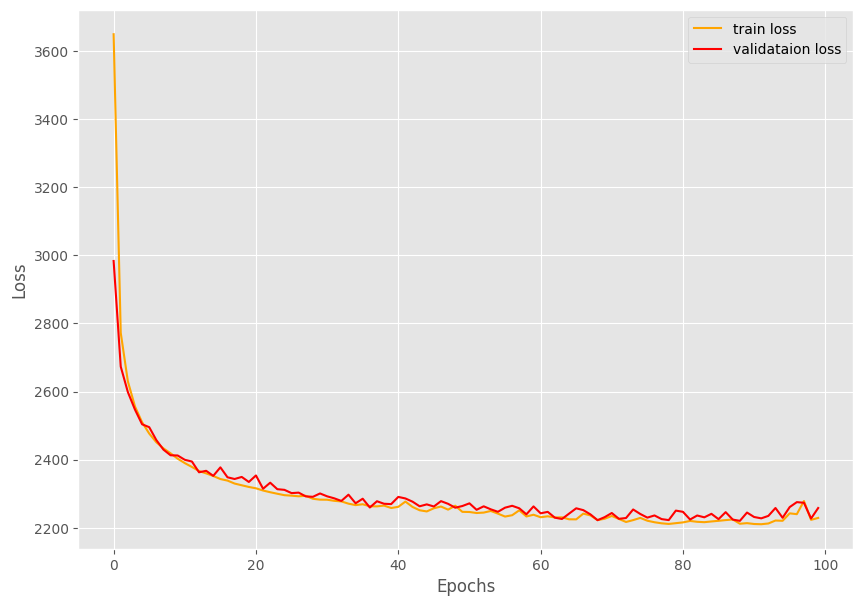

TRAINING COMPLETE


In [98]:
image_to_vid(grid_images)
# save the loss plots to disk
save_loss_plot(train_loss, valid_loss)
print('TRAINING COMPLETE')

In [99]:
torch.save(encoder, f'outputs/encoder')
torch.save(decoder, f'outputs/decoder')

In [100]:
newencoder = torch.load("outputs/encoder")
newdecoder = torch.load("outputs/decoder")

In [101]:
inputs, classes = next(iter(testloader))
inputs = inputs.to(device)
classes = classes.to(device)

In [102]:
z, mu, log_var = newencoder(inputs)

In [108]:
decoded = newdecoder(z, mu, log_var)
print(z[1], mu[1])

tensor([-1.6778, -0.3919], device='cuda:0', grad_fn=<SelectBackward0>) tensor([-1.6340, -0.4292], device='cuda:0', grad_fn=<SelectBackward0>)
